# FastWoe Softmax WOE: multiclass targets

Author: https://www.github.com/xRiskLab

The companion to `fastwoe_softmax.ipynb`, for a target with more than two classes. Here an account is **current**, **late** or in **default**.

**`SoftmaxWoe` is a generative classifier: per class, an autoregressive chain of penalized multinomial logistic regressions, fitted by maximum likelihood of the features given the class; its per-feature weights are Good's conditional weights of evidence under that model and sum exactly to the posterior log-odds.**

With two classes there are two chains, one among bads and one among goods. With $K$ classes there are $K$ chains, one per class, each describing how that class's applicants look, feature by feature. The class probabilities come from Bayes' rule, a softmax over classes:

$$P(k \mid x) = \frac{P(k) \prod_i P(x_i \mid x_{<i}, k)}{\sum_j P(j) \prod_i P(x_i \mid x_{<i}, j)}$$

so they always sum to 1. Each feature's evidence for class $k$ is its contribution to class $k$'s score, $\log P(x_i \mid x_{<i}, k)$.

The data is synthetic, from a known generator, so every probability and weight has a true value to compare against.

**Set `C` and `ORDER` in the next cell, then run all.**

In [1]:
C = 1.0  # inverse penalty strength: smaller = more shrinkage
N_TRAIN = 8000
SEED = 7

# Conditioning order: p(x1 | k) * p(x2 | x1, k) * p(x3 | x1, x2, k). Change it here; the rest follows.
ORDER = ["delinq", "util", "inq"]
# ORDER = ["util", "delinq", "inq"]
# ORDER = ["inq", "delinq", "util"]
FEATURE_1, FEATURE_2, FEATURE_3 = ORDER

CLASSES = {
    0: "current",
    1: "late",
    2: "default",
}  # labels may be anything; integers keep columns in this order

## The generator

The same three binned features as in the binary notebook, drawn in a fixed order (`GEN_ORDER`). Each class has its own chain: in each class the bin of every feature depends on the earlier bins, and how it depends differs from class to class. This is what one-vs-rest marginal WOE cannot capture.

The model's conditioning order is `ORDER`, set at the top; the true conditional probabilities for any `ORDER` come from the generator's exact joint distribution.

In [2]:
import itertools

import numpy as np
import pandas as pd

from fastwoe import FastWoe, SoftmaxWoe

pd.set_option("display.width", 80)
%config InlineBackend.figure_format = 'retina'

LEVELS = {
    "delinq": ["no", "yes"],
    "util": ["<30", "30-80", ">80"],
    "inq": ["0", "1-2", "3+"],
}
GEN_ORDER = list(LEVELS)  # the order the generator draws features in (fixed)
assert sorted(ORDER) == sorted(GEN_ORDER), "ORDER must list each feature once"
K = len(CLASSES)
PRIOR = np.array([0.75, 0.17, 0.08])  # current, late, default

rng = np.random.default_rng(SEED)
# true node scores per class: intercept per bin, plus one effect per earlier bin
TRUE = {}
for i, f in enumerate(GEN_ORDER):
    L = len(LEVELS[f])
    n_in = sum(len(LEVELS[g]) for g in GEN_ORDER[:i])
    for h in range(K):
        a = (
            rng.normal(0, 0.8, L) + np.linspace(-0.6, 0.6, L) * h
        )  # worse classes lean to later bins
        B = rng.normal(0, 0.9, (n_in, L)) * (1.0 + 0.3 * h)
        TRUE[(i, h)] = (a, B)


def softmax(z: np.ndarray) -> np.ndarray:
    """Softmax of each row."""
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def onehot(df: pd.DataFrame, feats: list[str]) -> np.ndarray:
    """One-hot of the given features, every bin kept, in LEVELS order."""
    blocks = [np.eye(len(LEVELS[f]))[pd.Categorical(df[f], LEVELS[f]).codes] for f in feats]
    return np.hstack(blocks) if blocks else np.zeros((len(df), 0))


def gen_probs(i: int, h: int, df: pd.DataFrame) -> np.ndarray:
    """Generator's P(bin of GEN_ORDER[i] | earlier bins in GEN_ORDER, class h): rows x bins."""
    a, B = TRUE[(i, h)]
    return softmax(a + onehot(df, GEN_ORDER[:i]) @ B)


# every possible profile, with its exact probability in each class
PROFILES = pd.DataFrame(list(itertools.product(*LEVELS.values())), columns=GEN_ORDER)
JOINT = {}
for h in range(K):
    lik = np.ones(len(PROFILES))
    for i, f in enumerate(GEN_ORDER):
        codes = pd.Categorical(PROFILES[f], LEVELS[f]).codes
        lik *= gen_probs(i, h, PROFILES)[np.arange(len(PROFILES)), codes]
    JOINT[h] = PROFILES.assign(p=lik)


def true_cond(f: str, h: int, df: pd.DataFrame, order: list[str] | None = None) -> np.ndarray:
    """True P(row's bin of f | its bins of the features before f in order, class h)."""
    order = ORDER if order is None else order
    before = order[: order.index(f)]
    joint = JOINT[h]
    num = joint.groupby(before + [f], as_index=False).p.sum()
    p = df[before + [f]].merge(num, how="left", on=before + [f]).p.to_numpy()
    if before:
        den = joint.groupby(before, as_index=False).p.sum()
        p = p / df[before].merge(den, how="left", on=before).p.to_numpy()
    return p


def true_log_probs(df: pd.DataFrame) -> np.ndarray:
    """True log P(bin | earlier bins, class) in ORDER: rows x features x classes."""
    return np.stack(
        [np.column_stack([np.log(true_cond(f, h, df)) for h in range(K)]) for f in ORDER], axis=1
    )


def true_posterior(df: pd.DataFrame) -> np.ndarray:
    """True P(class | profile): rows x classes."""
    return softmax(np.log(PRIOR) + true_log_probs(df).sum(axis=1))


def true_contributions(df: pd.DataFrame) -> np.ndarray:
    """True softmax contributions: log P(bin | earlier bins, class) centered over classes."""
    lp = true_log_probs(df)
    return lp - lp.mean(axis=2, keepdims=True)


def sample(n: int) -> pd.DataFrame:
    """Draw n accounts from the generator."""
    y = rng.choice(K, n, p=PRIOR)
    df = pd.DataFrame({"y": y})
    for i, f in enumerate(GEN_ORDER):
        df[f] = ""
        for h in range(K):
            m = (df.y == h).to_numpy()
            p = gen_probs(i, h, df[m])
            k = (p.cumsum(1) > rng.random((m.sum(), 1))).argmax(1)
            df.loc[m, f] = np.array(LEVELS[f])[k]
    return df[GEN_ORDER + ["y"]]


train, test = sample(N_TRAIN), sample(20_000)
counts = train.y.value_counts().sort_index()
print("train:", ", ".join(f"{counts[h]} {CLASSES[h]}" for h in range(K)))
print(f"{len(PROFILES)} possible profiles; conditioning order: {' > '.join(ORDER)}")
train.head()

train: 5990 current, 1365 late, 645 default
18 possible profiles; conditioning order: delinq > util > inq


,delinq,util,inq,y
0,no,30-80,1-2,0
1,yes,<30,1-2,0
2,no,30-80,1-2,0
3,yes,>80,1-2,1
4,yes,30-80,3+,0


## What the method does, in plain words

Take each class separately and describe how its accounts look, one feature at a time, looking only at accounts that match the applicant so far. In the default `ORDER`:

1. **Delinquency.** What share of current accounts, of late ones and of defaulted ones have the applicant's delinquency bin?
2. **Utilization, among accounts with that delinquency bin.** The same question, within each class.
3. **Inquiries, among accounts with that delinquency and utilization.** Same again.

Each class gets a **score**: its prior log-share plus the logs of its shares at every step. The softmax of the scores gives the class probabilities, which sum to 1. A feature's **contribution** to a class is its log-share there, measured against the average over the classes: positive if the applicant's bin is more typical of that class than of the classes on average.

**Where the softmax comes in.** Steps 2 and 3 need shares inside small groups, and with three classes the rarest class (default, 8%) thins out fast. So each step's shares are _predicted_, by a logistic regression on the earlier bins, fitted once per class. A small group borrows strength from the others.

## In plain scikit-learn

The whole method by hand, in the order set by `ORDER`. Each model's target is **never `y`**: `y` only splits the training rows into classes. Within each class, every model predicts a _feature's bin_ from the bins of the features before it:

| Node | Target            | Inputs                              | Fitted on                      |
| ---- | ----------------- | ----------------------------------- | ------------------------------ |
| 0    | `FEATURE_1`'s bin | nothing: just the share of each bin | each class separately (3 fits) |
| 1    | `FEATURE_2`'s bin | `FEATURE_1`                         | each class separately (3 fits) |
| 2    | `FEATURE_3`'s bin | `FEATURE_1` and `FEATURE_2`         | each class separately (3 fits) |

`node_1[k]` answers _"for an account of class k with this delinquency, how likely is each utilization bin?"_

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

by_class = {h: train[train.y == h] for h in range(K)}
print(f"order: {FEATURE_1} > {FEATURE_2} > {FEATURE_3}")


def shares(column: pd.Series) -> pd.Series:
    """Share of each bin, with 0.5 added to every count so no bin is exactly 0."""
    counts = column.value_counts().reindex(LEVELS[column.name], fill_value=0) + 0.5
    return counts / counts.sum()


def node_penalty(target: pd.Series) -> float:
    """The penalty for a node: 2C when its target has two bins, as SoftmaxWoe does.

    With two bins scikit-learn fits one logit instead of a coefficient row per bin,
    which the same C would penalize twice as hard as a softmax with three or more.
    """
    return 2 * C if target.nunique() == 2 else C


def node_model(inputs: list[str], target: str, rows: pd.DataFrame) -> LogisticRegression:
    """One node for one class: the target feature's bin from the earlier bins, one-hot."""
    return LogisticRegression(C=node_penalty(rows[target]), max_iter=5000).fit(
        onehot(rows, inputs), rows[target]
    )


# -------------------------------------------------------------------------------
# node 0, FEATURE_1: no model, just the share of each bin, in every class
# -------------------------------------------------------------------------------
node_0 = {h: shares(by_class[h][FEATURE_1]) for h in range(K)}
print(f"\n{FEATURE_1} shares by class:")
print(pd.DataFrame({CLASSES[h]: node_0[h] for h in range(K)}).round(3))

# -------------------------------------------------------------------------------
# node 1, FEATURE_2: target is FEATURE_2's bin, input is FEATURE_1; one model per class
# -------------------------------------------------------------------------------
node_1 = {h: node_model([FEATURE_1], FEATURE_2, by_class[h]) for h in range(K)}

# -------------------------------------------------------------------------------
# node 2, FEATURE_3: target is FEATURE_3's bin, inputs are FEATURE_1 and FEATURE_2
# -------------------------------------------------------------------------------
node_2 = {h: node_model([FEATURE_1, FEATURE_2], FEATURE_3, by_class[h]) for h in range(K)}

for h in range(K):
    print(f"\n{CLASSES[h]}: {FEATURE_3} model coefficients\n{node_2[h].coef_.round(2)}")

order: delinq > util > inq

delinq shares by class:
        current   late  default
delinq                         
no        0.441  0.313    0.134
yes       0.559  0.687    0.866

current: inq model coefficients
[[-0.55 -0.43 -0.41 -0.23 -0.35]
 [ 0.95  0.17 -0.26  0.59  0.79]
 [-0.39  0.27  0.67 -0.36 -0.44]]

late: inq model coefficients
[[-0.23  0.22  0.   -0.55  0.54]
 [-0.26  0.26 -0.62 -0.21  0.84]
 [ 0.49 -0.49  0.62  0.77 -1.38]]

default: inq model coefficients
[[-0.75  0.75 -0.56 -0.02  0.57]
 [-0.26  0.26  1.08  0.17 -1.25]
 [ 1.01 -1.01 -0.52 -0.15  0.67]]


For every applicant, ask each class's model at each node how likely the applicant's _actual_ bin is. A class's score is its prior log-share plus those log-probabilities, a plain row sum, and the softmax of the scores gives the probabilities: Bayes' rule with $K$ hypotheses.

$$\text{score}_k = \log P(k) + \sum_i \log P(\text{bin}_i \mid \text{earlier bins}, k), \qquad P(k \mid \text{applicant}) = \text{softmax}_k(\text{score})$$

A feature's **contribution** to class $k$ is its log-probability centered over the classes. Centering removes what all classes share, and the softmax ignores anything shared, so the contributions give the same probabilities.

In [4]:
def own_bin_prob(model: LogisticRegression, X: np.ndarray, observed: pd.Series) -> np.ndarray:
    """Each row's predicted probability of the bin it actually has."""
    columns = pd.Index(model.classes_).get_indexer(observed)
    return model.predict_proba(X)[np.arange(len(X)), columns]


# -------------------------------------------------------------------------------
# log P(the row's own bin | earlier bins, class k), per feature and class
# -------------------------------------------------------------------------------
X1, X12 = onehot(test, [FEATURE_1]), onehot(test, [FEATURE_1, FEATURE_2])
manual_logp = np.stack(
    [
        np.column_stack([np.log(node_0[h][test[FEATURE_1]].to_numpy()) for h in range(K)]),
        np.column_stack([np.log(own_bin_prob(node_1[h], X1, test[FEATURE_2])) for h in range(K)]),
        np.column_stack([np.log(own_bin_prob(node_2[h], X12, test[FEATURE_3])) for h in range(K)]),
    ],
    axis=1,
)  # rows x features (ORDER) x classes

manual_log_prior = np.log(np.array([len(by_class[h]) for h in range(K)]) / len(train))
manual_scores = manual_log_prior + manual_logp.sum(axis=1)  # it's just a sum, per class
manual_proba = softmax(manual_scores)
manual_contrib = manual_logp - manual_logp.mean(axis=2, keepdims=True)  # centered over classes

print("mean predicted vs observed share:")
for h in range(K):
    print(f"  {CLASSES[h]:8} {manual_proba[:, h].mean():.4f}  {(test.y == h).mean():.4f}")
print(f"Manual log loss: {log_loss(test.y, manual_proba):.4f}")

mean predicted vs observed share:
  current  0.7533  0.7520
  late     0.1663  0.1670
  default  0.0804  0.0810
Manual log loss: 0.5154


One applicant, row by row through the nodes: each class's probability of the applicant's bin, the contributions, and the class probabilities after each step:

In [5]:
a = 0  # row of the test set
print(", ".join(f"{f}={test[f].iloc[a]}" for f in ORDER), "| actually", CLASSES[test.y.iloc[a]])
running = manual_log_prior.copy()
names = [CLASSES[h] for h in range(K)]
print(f"{'':16}" + "".join(f"{n:>10}" for n in names))
print(f"{'prior share':16}" + "".join(f"{v:10.3f}" for v in softmax(running[None])[0]))
for i, f in enumerate(ORDER):
    p = np.exp(manual_logp[a, i])
    running = running + manual_logp[a, i]
    print(
        f"{f + '=' + test[f].iloc[a]:16}" + "".join(f"{v:10.3f}" for v in p) + "   P(bin | class)"
    )
    print(f"{'  contribution':16}" + "".join(f"{v:+10.3f}" for v in manual_contrib[a, i]))
    print(f"{'  P(class) now':16}" + "".join(f"{v:10.3f}" for v in softmax(running[None])[0]))

delinq=no, util=30-80, inq=1-2 | actually current
                   current      late   default
prior share          0.749     0.171     0.081
delinq=no            0.441     0.313     0.134   P(bin | class)
  contribution      +0.512    +0.168    -0.680
  P(class) now       0.837     0.135     0.027
util=30-80           0.738     0.253     0.515   P(bin | class)
  contribution      +0.477    -0.594    +0.117
  P(class) now       0.927     0.051     0.021
inq=1-2              0.964     0.364     0.288   P(bin | class)
  contribution      +0.728    -0.246    -0.482
  P(class) now       0.973     0.020     0.007


## Fit SoftmaxWoe

`SoftmaxWoe` does exactly the above for any number of classes and features, and also bins numerical features. With three or more classes it fits one chain per class; `predict_proba` is the softmax of the class scores, one column per class in `model.classes_`.

In [6]:
model = SoftmaxWoe(order=ORDER, C=C).fit(train[ORDER], train.y)
print("classes:", model.classes_, "| log prior:", model.class_log_prior_.round(3))
proba = model.predict_proba(test[ORDER])
print(
    f"largest difference from the plain scikit-learn probabilities: {np.abs(proba - manual_proba).max():.1e}"
)
contributions = model.transform(test[ORDER])  # columns {feature}_class_{k}
manual_frame = manual_contrib.reshape(len(test), -1)
print(
    f"largest difference in contributions: {np.abs(contributions.to_numpy() - manual_frame).max():.1e}"
)
contributions.head().round(3)

classes: [0 1 2] | log prior: [-0.289 -1.768 -2.518]
largest difference from the plain scikit-learn probabilities: 2.7e-14


largest difference in contributions: 3.8e-13


,delinq_class_0,delinq_class_1,delinq_class_2,util_class_0,util_class_1,util_class_2,inq_class_0,inq_class_1,inq_class_2
0,0.512,0.168,-0.68,0.477,-0.594,0.117,0.728,-0.246,-0.482
1,0.512,0.168,-0.68,0.477,-0.594,0.117,0.728,-0.246,-0.482
2,0.512,0.168,-0.68,-0.633,0.351,0.282,1.086,0.984,-2.070
3,0.512,0.168,-0.68,-0.313,0.832,-0.520,0.460,-0.573,0.113
4,0.512,0.168,-0.68,-0.633,0.351,0.282,1.086,0.984,-2.070


## The bins at each node

For every path of earlier bins: each class's fitted P(bin | class) from `node_proba` next to the true value, and how many training accounts of each class sit on that path. The rare class is where the fitted values stray most.

In [7]:
def show_node(f: str) -> None:
    """Print each class's fitted and true probabilities of every bin of f, per path of earlier bins."""
    i = ORDER.index(f)
    print(f"node {i}: {f}")
    for path in itertools.product(*[LEVELS[g] for g in ORDER[:i]]):
        given = dict(zip(ORDER[:i], path))
        rows = pd.DataFrame([given] * len(LEVELS[f]), columns=ORDER[:i])
        rows[f] = LEVELS[f]
        p = model.node_proba(rows, f)
        on = (train[ORDER[:i]] == pd.Series(given)).all(1) if i else train.y >= 0
        n_by_class = train.y[on].value_counts().reindex(range(K), fill_value=0)
        label = ", ".join(f"{g}={v}" for g, v in given.items()) or "(nothing yet)"
        print(
            f"given {label}   ["
            + ", ".join(f"{n_by_class[h]} {CLASSES[h]}" for h in range(K))
            + "]"
        )
        out = pd.DataFrame(index=LEVELS[f])
        for h in range(K):
            out[f"P|{CLASSES[h]}"] = p[f"p_class_{h}"].to_numpy()
            out[f"true|{CLASSES[h]}"] = true_cond(f, h, rows)
        print(out.round(3).to_string(), "\n")


for f in ORDER:
    show_node(f)

node 0: delinq
given (nothing yet)   [5990 current, 1365 late, 645 default]
     P|current  true|current  P|late  true|late  P|default  true|default
no       0.441         0.441   0.313       0.33      0.134         0.122
yes      0.559         0.559   0.687       0.67      0.866         0.878 

node 1: util
given delinq=no   [2643 current, 427 late, 86 default]
       P|current  true|current  P|late  true|late  P|default  true|default
<30        0.100         0.099   0.314      0.318      0.081         0.106
30-80      0.738         0.748   0.253      0.232      0.515         0.542
>80        0.162         0.153   0.432      0.450      0.403         0.352 



given delinq=yes   [3347 current, 938 late, 559 default]
       P|current  true|current  P|late  true|late  P|default  true|default
<30        0.385         0.375   0.274      0.286      0.064         0.065
30-80      0.395         0.411   0.020      0.030      0.763         0.748
>80        0.220         0.214   0.706      0.683      0.172         0.187 

node 2: inq
given delinq=no, util=<30   [264 current, 134 late, 7 default]
     P|current  true|current  P|late  true|late  P|default  true|default
0        0.017         0.025   0.053      0.046      0.010         0.004
1-2      0.837         0.819   0.298      0.293      0.592         0.851
3+       0.146         0.156   0.649      0.662      0.398         0.145 

given delinq=no, util=30-80   [1952 current, 109 late, 44 default]
     P|current  true|current  P|late  true|late  P|default  true|default
0        0.010         0.011   0.025      0.012      0.021         0.009
1-2      0.964         0.960   0.364      0.356      0.288 

## One applicant, step by step

Change `who` to follow another applicant. Each feature's contribution to each class, next to the true contribution, and the class probabilities as the evidence arrives.

In [8]:
who: int = 0
app = test.iloc[[who]]
contrib = model.transform(app[ORDER]).to_numpy()[0].reshape(len(ORDER), K)
true_c = true_contributions(app)[0]
print(", ".join(f"{f}={app[f].iloc[0]}" for f in ORDER), "| actually", CLASSES[app.y.iloc[0]])
print(f"{'':16}" + "".join(f"{CLASSES[h]:>17}" for h in range(K)))
print(f"{'':16}" + "".join(f"{'fitted':>9}{'true':>8}" for h in range(K)))
score = model.class_log_prior_.copy()
for i, f in enumerate(ORDER):
    score = score + contrib[i]
    print(f"{f:16}" + "".join(f"{contrib[i, h]:+9.3f}{true_c[i, h]:+8.3f}" for h in range(K)))
print(
    f"{'P(class)':16}"
    + "".join(f"{p:9.3f}{t:8.3f}" for p, t in zip(softmax(score[None])[0], true_posterior(app)[0]))
)
print(
    "predict_proba:  ",
    model.predict_proba(app[ORDER])[0].round(3),
    "| predict:",
    CLASSES[model.predict(app[ORDER])[0]],
)

delinq=no, util=30-80, inq=1-2 | actually current
                          current             late          default
                   fitted    true   fitted    true   fitted    true
delinq             +0.512  +0.523   +0.168  +0.235   -0.680  -0.758
util               +0.477  +0.498   -0.594  -0.673   +0.117  +0.175
inq                +0.728  +0.616   -0.246  -0.376   -0.482  -0.240
P(class)            0.973   0.972    0.020   0.019    0.007   0.009
predict_proba:   [0.973 0.02  0.007] | predict: current


## Three ways to read the weights

All three add up exactly; they answer different questions.

- **Softmax contributions** (`transform(X)`, the default): each feature's contribution to each class's score, centered over the classes, as a multinomial logistic regression reports its coefficients. Softmax of the class log-prior plus each class's summed contributions gives `predict_proba`.
- **One-vs-rest** (`transform(X, against="rest")`): class $k$ against all the others. "Not $k$" is a composite hypothesis, the mixture of the other classes, weighted by their prior times the evidence so far (Good's weighted average of factors). Class $k$'s prior log-odds plus its summed weights is its posterior log-odds against the rest. This is the meaning of FastWoe's multiclass columns.
- **Against one class** (`transform(X, against=0)`): each class against "current". The prior ratio plus the summed weights is the log of the two classes' probability ratio.

In [9]:
from scipy.special import logit

x = test[ORDER].head(1000)
p = model.predict_proba(x)
log_prior = model.class_log_prior_


def summed(frame: pd.DataFrame, h: int) -> np.ndarray:
    """Row sum of class h's columns."""
    return frame.filter(like=f"_class_{h}").sum(axis=1).to_numpy()


softmax_w = model.transform(x)
rebuilt = softmax(log_prior + np.column_stack([summed(softmax_w, h) for h in range(K)]))
print(
    f"softmax contributions -> predict_proba:          max |diff| {np.abs(rebuilt - p).max():.1e}"
)

ovr = model.transform(x, against="rest")
prior_log_odds = log_prior - np.log1p(-np.exp(log_prior))
err = max(np.abs(prior_log_odds[h] + summed(ovr, h) - logit(p[:, h])).max() for h in range(K))
print(f"one-vs-rest -> each class's log-odds vs the rest: max |diff| {err:.1e}")

vs_current = model.transform(x, against=0)
err = max(
    np.abs(log_prior[h] - log_prior[0] + summed(vs_current, h) - np.log(p[:, h] / p[:, 0])).max()
    for h in (1, 2)
)
print(f"against current -> log P(k) / P(current):        max |diff| {err:.1e}")
pd.concat({"softmax": softmax_w.head(3), "one-vs-rest": ovr.head(3)}, axis=1).filter(
    like="delinq"
).round(3)

softmax contributions -> predict_proba:          max |diff| 4.4e-16
one-vs-rest -> each class's log-odds vs the rest: max |diff| 3.1e-15
against current -> log P(k) / P(current):        max |diff| 1.1e-15


softmax                                  one-vs-rest                 \
  delinq_class_0 delinq_class_1 delinq_class_2 delinq_class_0 delinq_class_1   
0          0.512          0.168          -0.68          0.546         -0.273   
1          0.512          0.168          -0.68          0.546         -0.273   
2          0.512          0.168          -0.68          0.546         -0.273   

                  
  delinq_class_2  
0         -1.137  
1         -1.137  
2         -1.137

## The softmax step by step

Take the profile in `EXAMPLE` (delinquent, utilization over 80%, 3+ inquiries). Given its bins of the first two features in `ORDER`, which bin of the last one comes next? Each class's node answers, in the four steps of the binary notebook: score each bin, exponentiate, divide by the total, then read the applicant's bin. With three classes the last step gives three probabilities, and the contributions are their logs centered over the classes.

In [10]:
EXAMPLE = {"delinq": "yes", "util": ">80", "inq": "3+"}  # one profile, used here and below

f = FEATURE_3  # the last node
i = ORDER.index(f)
path = {g: EXAMPLE[g] for g in ORDER[:i]}  # the earlier bins
observed = EXAMPLE[f]  # the bin the applicant has at this node
cols = [(g, b) for g in ORDER[:i] for b in model.levels_[g]]
x_onehot = np.array([1.0 if path[g] == b else 0.0 for g, b in cols])
bins = model.levels_[f]


def softmax_rows(m) -> tuple[np.ndarray, np.ndarray]:
    """Intercept and coefficients with one row per bin (a two-bin node stores one logit)."""
    if m.coef_.shape[0] == 1:
        return np.r_[0.0, m.intercept_], np.vstack([np.zeros_like(m.coef_), m.coef_])
    return m.intercept_, m.coef_


P = {}
for h in range(K):
    intercept, coef = softmax_rows(model.nodes_[(f, h)])
    z = intercept + coef @ x_onehot
    P[h] = np.exp(z) / np.exp(z).sum()
    print(f"--- if the account is {CLASSES[h]} ---")
    print("   scores " + "  ".join(f"{b}: {v:+.2f}" for b, v in zip(bins, z)))
    print("   shares " + "  ".join(f"{b}: {v:.3f}" for b, v in zip(bins, P[h])))

k = bins.index(observed)
logp_bin = np.log([P[h][k] for h in range(K)])
print(
    f"\nP({f}={observed} | {path}, class):",
    "  ".join(f"{CLASSES[h]} {np.exp(v):.3f}" for h, v in enumerate(logp_bin)),
)
print(
    "contributions (centered logs):     ",
    "  ".join(f"{CLASSES[h]} {v:+.3f}" for h, v in enumerate(logp_bin - logp_bin.mean())),
)
row = pd.DataFrame([{**path, f: observed}])
print(
    "model.transform gives the same:     ",
    "  ".join(
        f"{CLASSES[h]} {model.transform(row)[f'{f}_class_{h}'].iloc[0]:+.3f}" for h in range(K)
    ),
)

--- if the account is current ---
   scores 0: -1.84  1-2: +2.16  3+: -0.31
   shares 0: 0.017  1-2: 0.907  3+: 0.077
--- if the account is late ---
   scores 0: -0.42  1-2: +2.30  3+: -1.88
   shares 0: 0.061  1-2: 0.925  3+: 0.014
--- if the account is default ---
   scores 0: +0.05  1-2: -0.31  3+: +0.26
   shares 0: 0.340  1-2: 0.237  3+: 0.423

P(inq=3+ | {'delinq': 'yes', 'util': '>80'}, class): current 0.077  late 0.014  default 0.423
contributions (centered logs):      current -0.004  late -1.700  default +1.704
model.transform gives the same:      current -0.004  late -1.700  default +1.704


## Why the probabilities add up exactly

Each node is a proper distribution over its bins, so in each class the product along the path is a proper distribution over all profiles. All three sums below are 1, so the softmax of the class scores is Bayes' rule under the fitted chains.

In [11]:
grid = PROFILES[ORDER]
lik = np.ones((len(grid), K))
for f in ORDER:
    lik *= model.node_proba(grid, f)[[f"p_class_{h}" for h in range(K)]].to_numpy()
for h in range(K):
    print(f"sum of P(profile | {CLASSES[h]}) over {len(grid)} profiles = {lik[:, h].sum():.6f}")

sum of P(profile | current) over 18 profiles = 1.000000
sum of P(profile | late) over 18 profiles = 1.000000
sum of P(profile | default) over 18 profiles = 1.000000


## Impact of C

Holdout log loss and the average error of the softmax contributions against the truth, across a range of `C`. For comparison: FastWoe's multiclass mode (one-vs-rest marginal WOE), a multinomial logistic regression on the one-hot features (one model for all classes, main effects only), and the true posterior.

In [12]:
y = test.y.to_numpy()
X_train, X_test = train[ORDER], test[ORDER]
true_c = true_contributions(test).reshape(len(test), -1)


def row(name: str, proba: np.ndarray, contrib: np.ndarray | None = None) -> dict:
    """Holdout log loss, and mean absolute error of the contributions against the truth."""
    error = np.abs(contrib - true_c).mean() if contrib is not None else np.nan
    return {"model": name, "log loss": log_loss(y, proba), "contribution error": error}


rows = [
    row("FastWoe, one-vs-rest WOE", FastWoe().fit(X_train, train.y).predict_proba(X_test)),
    row(
        "multinomial logistic regression",
        LogisticRegression(max_iter=5000)
        .fit(onehot(train, ORDER), train.y)
        .predict_proba(onehot(test, ORDER)),
    ),
]
for c in (0.001, 0.01, 0.1, 1, 10, 100):
    m = SoftmaxWoe(order=ORDER, C=c).fit(X_train, train.y)
    rows.append(row(f"softmax C={c:g}", m.predict_proba(X_test), m.transform(X_test).to_numpy()))
rows.append(row("true posterior", true_posterior(test), true_c))
pd.DataFrame(rows).set_index("model").round(4).style.background_gradient(cmap="viridis_r")

,log loss,contribution error
model,,
"FastWoe, one-vs-rest WOE",0.581500,nan
multinomial logistic regression,0.570800,nan
softmax C=0.001,0.556100,0.245100
softmax C=0.01,0.527300,0.160000
softmax C=0.1,0.516400,0.070700
softmax C=1,0.515400,0.072300
softmax C=10,0.515400,0.071700
softmax C=100,0.515400,0.071900
true posterior,0.514200,0.000000


## Standard errors

`transform(X, output="se")` gives the standard error of every contribution, and `predict_ci` an interval for every class's probability. The class chains are fitted on separate rows, and within a class the nodes have separate coefficients, so each class's score has its own variance, the sum of its node variances. A contribution, centered over the classes, gets (1 − 2/K)·V_k + ΣV_j/K². A class probability's interval comes from its log-odds against the rest, by the delta method through the softmax, plus the class priors' variance.

The same applicant as above, now with intervals:

In [13]:
contrib = model.transform(app[ORDER]).to_numpy()[0].reshape(len(ORDER), K)
se = model.transform(app[ORDER], output="se").to_numpy()[0].reshape(len(ORDER), K)
true_c = true_contributions(app)[0]
print(f"{'':10}" + "".join(f"{CLASSES[h]:>24}" for h in range(K)))
print(f"{'':10}" + "".join(f"{'fitted':>9}{'SE':>7}{'true':>8}" for h in range(K)))
for i, f in enumerate(ORDER):
    print(
        f"{f:10}"
        + "".join(f"{contrib[i, h]:+9.3f}{se[i, h]:7.3f}{true_c[i, h]:+8.3f}" for h in range(K))
    )
ci = model.predict_ci(app[ORDER])[0]
p_fit, p_true = model.predict_proba(app[ORDER])[0], true_posterior(app)[0]
for h in range(K):
    print(
        f"P({CLASSES[h]}) = {p_fit[h]:.4f}, 95% interval [{ci[2 * h]:.4f}, {ci[2 * h + 1]:.4f}], true {p_true[h]:.4f}"
    )

                           current                    late                 default
             fitted     SE    true   fitted     SE    true   fitted     SE    true
delinq       +0.512  0.037  +0.523   +0.168  0.043  +0.235   -0.680  0.068  -0.758
util         +0.477  0.045  +0.498   -0.594  0.065  -0.673   +0.117  0.075  +0.175
inq          +0.728  0.081  +0.616   -0.246  0.106  -0.376   -0.482  0.146  -0.240
P(current) = 0.9730, 95% interval [0.9652, 0.9791], true 0.9721
P(late) = 0.0204, 95% interval [0.0151, 0.0274], true 0.0190
P(default) = 0.0066, 95% interval [0.0040, 0.0109], true 0.0089


## Do the intervals cover the truth?

Draw a fresh training set, fit, compute the 95% interval for every class's probability on each of the 18 profiles, check whether it contains the true probability, and repeat. At the notebook's `C` and at C = 100 (barely penalized).

In [14]:
REPS = 200
profiles = PROFILES[ORDER]
true_p = true_posterior(profiles)  # profiles x classes
sim = {}
for c in (C, 100.0):
    ci = np.zeros((REPS, len(profiles), 2 * K))
    for r in range(REPS):
        d = sample(N_TRAIN)
        ci[r] = SoftmaxWoe(order=ORDER, C=c).fit(d[ORDER], d.y).predict_ci(profiles)
    sim[c] = ci

covered = {c: (ci[:, :, 0::2] <= true_p) & (true_p <= ci[:, :, 1::2]) for c, ci in sim.items()}
coverage = pd.DataFrame(
    {
        (f"C={c:g}", CLASSES[h]): cov[:, :, h].mean(0)
        for c, cov in covered.items()
        for h in range(K)
    },
    index=profiles.apply(lambda r: ", ".join(r), axis=1),
)
print(coverage.mean().unstack()[[CLASSES[h] for h in range(K)]].round(3).to_string())
coverage.round(3)

       current   late  default
C=1      0.950  0.952    0.942
C=100    0.957  0.954    0.957


C=1                  C=100               
                current   late default current   late default
no, <30, 0        0.970  0.975   0.930   0.965  0.965   0.970
no, <30, 1-2      0.945  0.955   0.960   0.930  0.960   0.930
no, <30, 3+       0.970  0.970   0.950   0.960  0.965   0.970
no, 30-80, 0      0.905  0.950   0.890   0.970  0.950   0.965
no, 30-80, 1-2    0.925  0.925   0.955   0.955  0.935   0.980
no, 30-80, 3+     0.955  0.975   0.965   0.940  0.915   0.925
no, >80, 0        0.945  0.945   0.900   0.955  0.940   0.965
no, >80, 1-2      0.945  0.940   0.960   0.950  0.950   0.975
no, >80, 3+       0.955  0.945   0.960   0.945  0.970   0.950
yes, <30, 0       0.955  0.940   0.950   0.975  0.960   0.960
yes, <30, 1-2     0.950  0.950   0.970   0.975  0.960   0.930
yes, <30, 3+      0.970  0.960   0.945   0.975  0.975   0.985
yes, 30-80, 0     0.955  0.945   0.955   0.940  0.970   0.945
yes, 30-80, 1-2   0.945  0.955   0.950   0.955  0.950   0.960
yes, 30-80, 3+    0.945  0.940   0.935   0.945  0.950   0.925
yes, >80, 0       0.960  0.965   0.935   0.950  0.955   0.955
yes, >80, 1-2     0.945  0.960   0.925   0.965  0.960   0.965
yes, >80, 3+      0.965  0.935   0.920   0.980  0.945   0.970

### One profile, many samples

For the `EXAMPLE` profile, the 95% interval for each class's probability from 100 training samples, sorted by estimate. About 1 in 20 should miss.

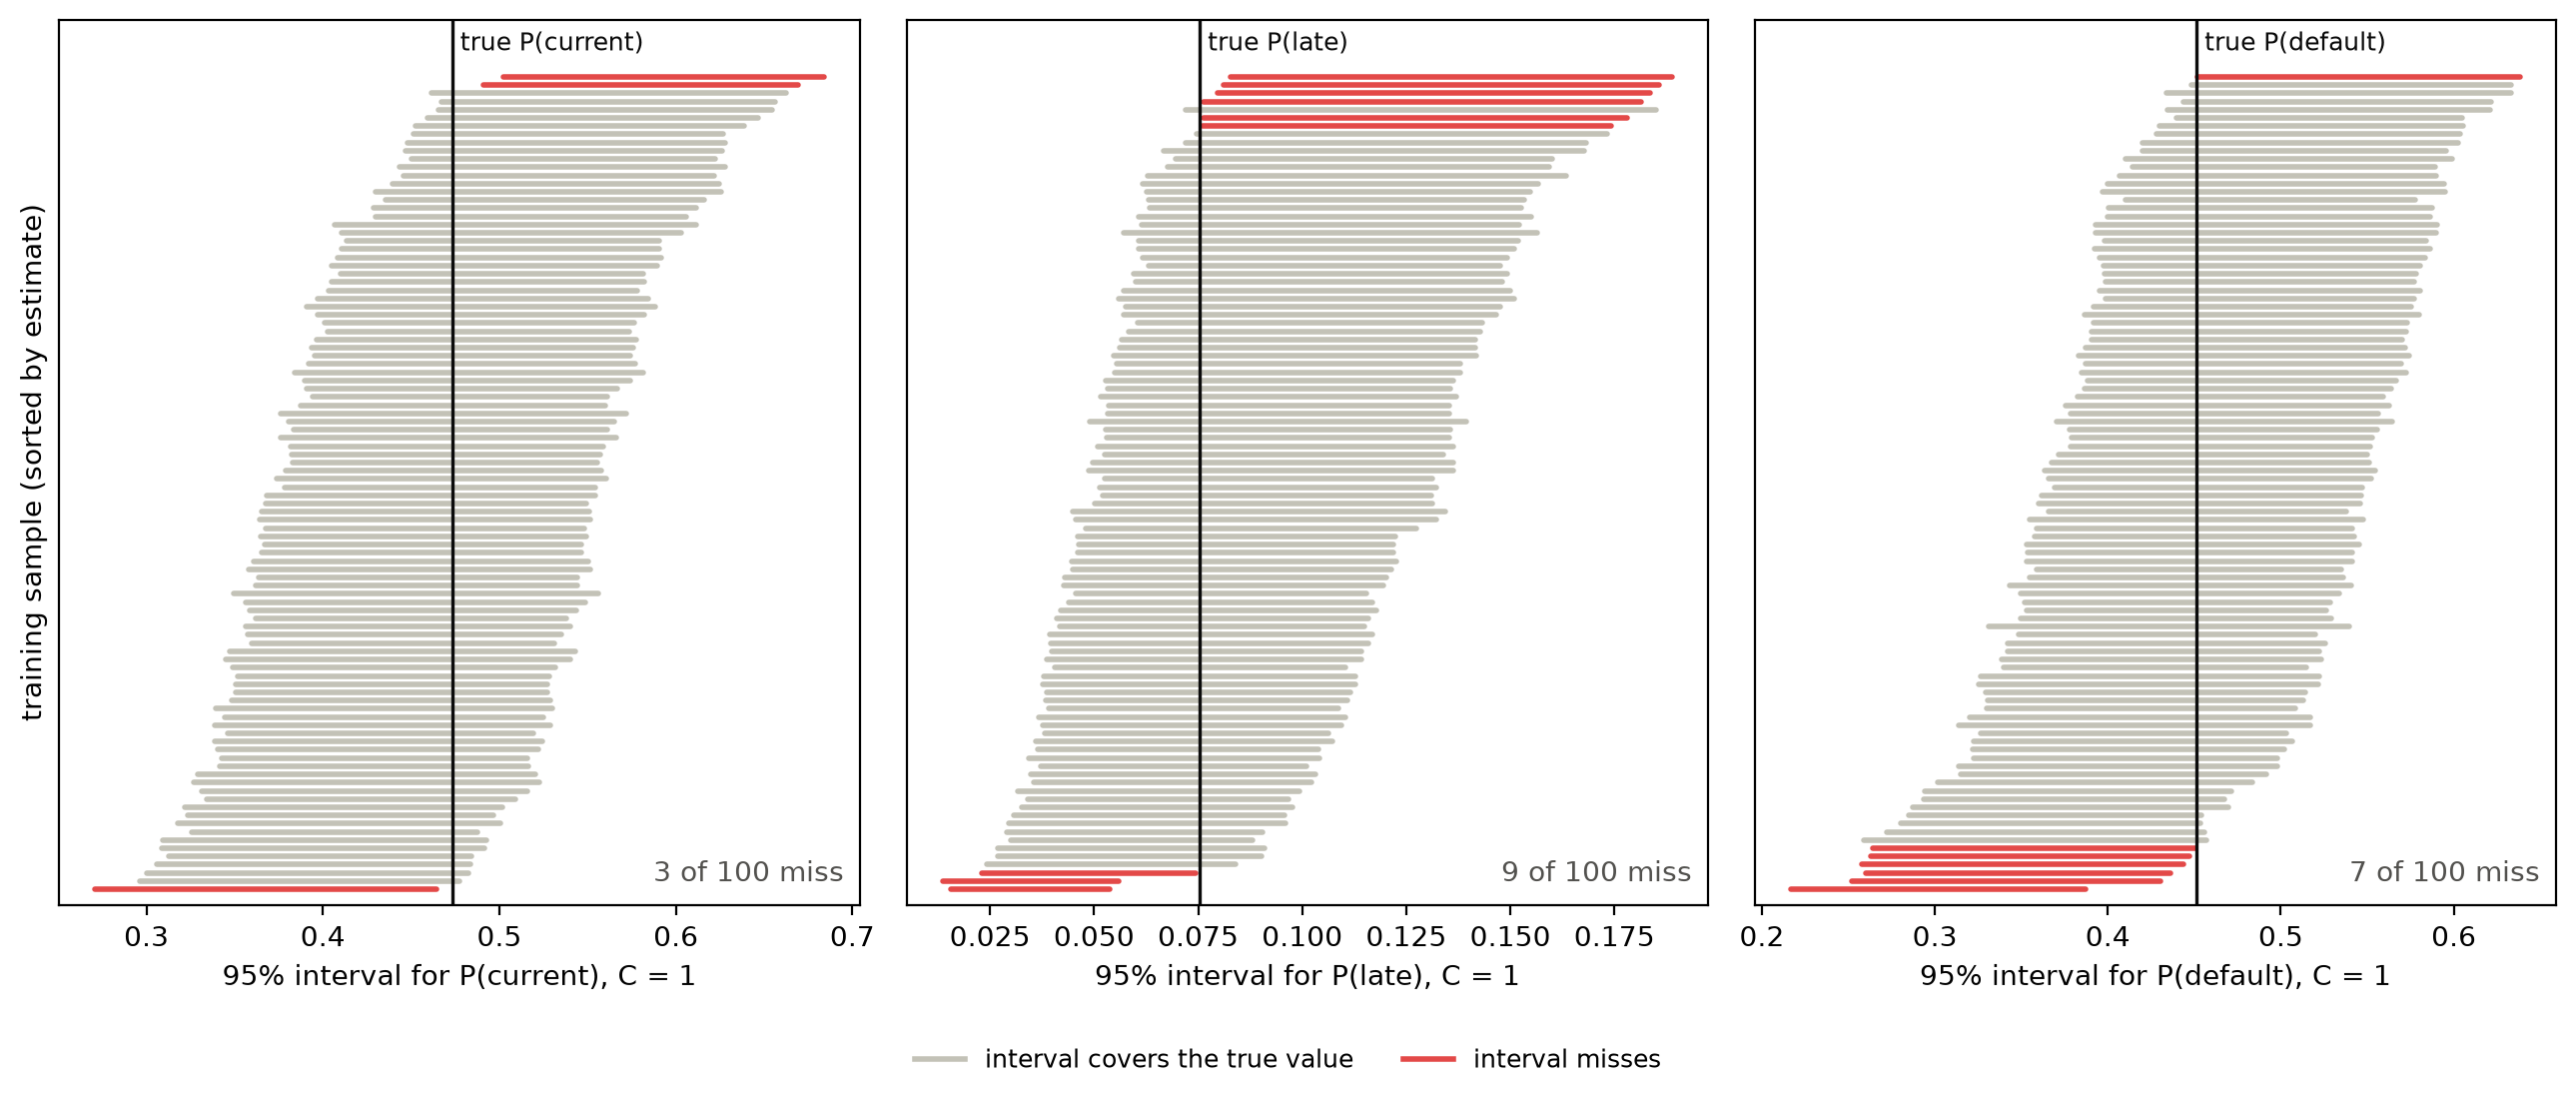

In [15]:
from matplotlib import pyplot as plt

COVERS, MISSES = "#c3c2b7", "#e34948"  # context gray, misses highlighted

who_profile = profiles.index[(profiles[list(EXAMPLE)] == pd.Series(EXAMPLE)).all(axis=1)][0]
shown = 100
fig, axes = plt.subplots(1, K, figsize=(13, 5.5), sharey=True)
for h, ax in enumerate(axes):
    lo_hi = sim[C][:shown, who_profile, 2 * h : 2 * h + 2]
    truth = true_p[who_profile, h]
    hit = (lo_hi[:, 0] <= truth) & (truth <= lo_hi[:, 1])
    for row_, k in enumerate(np.argsort(lo_hi.mean(1))):
        ax.plot(
            lo_hi[k], [row_, row_], color=COVERS if hit[k] else MISSES, lw=2, solid_capstyle="round"
        )
    ax.axvline(truth, color="#0b0b0b", lw=1.2)
    ax.text(truth, shown + 1.5, f" true P({CLASSES[h]})", color="#0b0b0b", va="bottom", fontsize=9)
    ax.set_xlabel(f"95% interval for P({CLASSES[h]}), C = {C:g}")
    ax.text(
        0.98,
        0.02,
        f"{(~hit).sum()} of {shown} miss",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        color="#52514e",
        fontsize=10,
    )
    ax.set_ylim(-2, shown + 6)
axes[0].set_ylabel("training sample (sorted by estimate)")
axes[0].set_yticks([])
handles = [
    plt.Line2D([], [], color=COVERS, lw=2, label="interval covers the true value"),
    plt.Line2D([], [], color=MISSES, lw=2, label="interval misses"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### Coverage across all 18 profiles

The share of samples whose interval covers the truth, per profile and class, at the notebook's `C`. With 200 samples, a correctly calibrated 95% interval lands inside the gray band about 95% of the time.

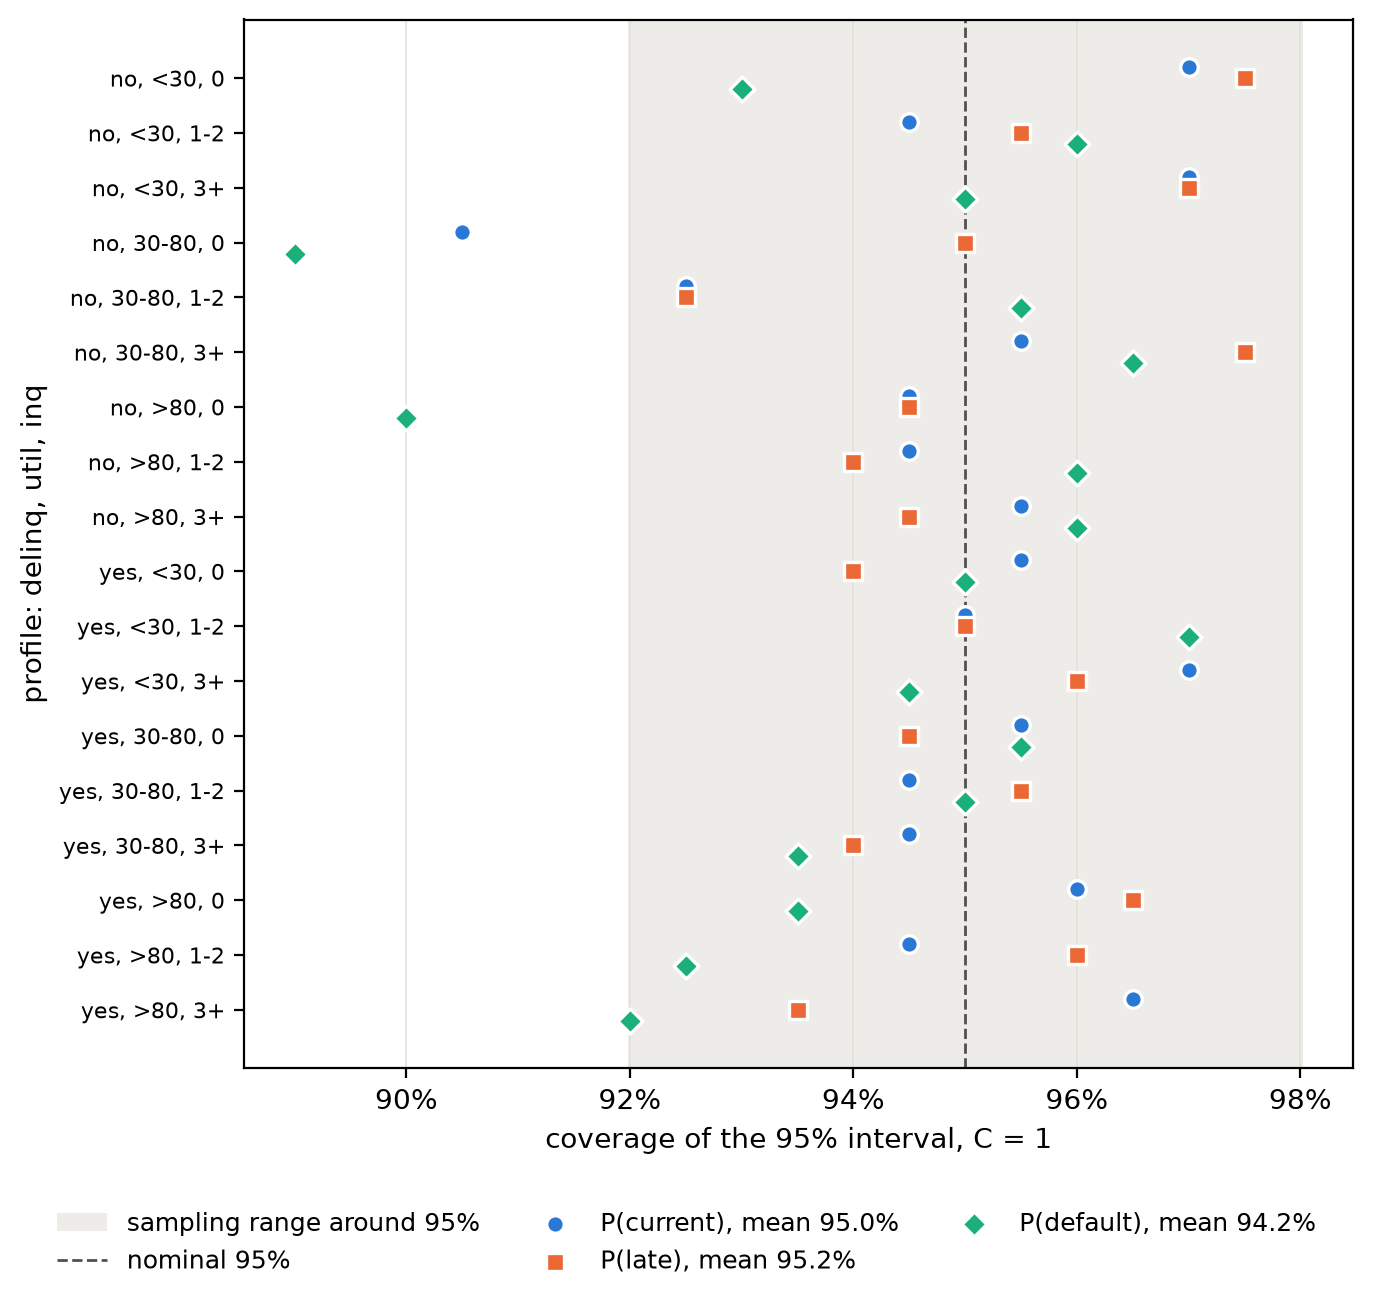

In [16]:
band = 1.96 * np.sqrt(0.95 * 0.05 / REPS)
SERIES = {0: ("#2a78d6", "o"), 1: ("#eb6834", "s"), 2: ("#1baf7a", "D")}
fig, ax = plt.subplots(figsize=(7, 6.5))
rows = np.arange(len(coverage))
ax.axvspan(
    0.95 - band, 0.95 + band, color="#e1e0d9", alpha=0.6, lw=0, label="sampling range around 95%"
)
ax.axvline(0.95, color="#52514e", lw=1, ls="--", label="nominal 95%")
for h, offset in zip(range(K), (-0.2, 0.0, 0.2)):
    color, marker = SERIES[h]
    values = coverage[(f"C={C:g}", CLASSES[h])]
    ax.scatter(
        values,
        rows + offset,
        color=color,
        marker=marker,
        s=40,
        edgecolor="white",
        linewidth=1.2,
        zorder=3,
        label=f"P({CLASSES[h]}), mean {values.mean():.1%}",
    )
ax.set_yticks(rows, coverage.index, fontsize=8)
ax.set_ylabel(f"profile: {', '.join(ORDER)}")
ax.invert_yaxis()
ax.set_xlabel(f"coverage of the 95% interval, C = {C:g}")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.grid(axis="x", color="#e1e0d9", lw=0.6)
ax.set_axisbelow(True)
fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

With the penalty almost off (C = 100) the intervals cover the truth at close to the nominal 95% rate for every class (95.4 to 95.7% on average). At the notebook's C = 1, current and late accounts stay at 95%, and default, the rarest class (645 training accounts), slips to 94.2%, with its lowest profiles at 89 to 92.5%. With fewer rows behind each of its nodes, the same penalty pulls them further toward the class's marginal shares. As in the binary notebook, the interval measures sampling noise, not the penalty's bias; with a strong penalty, read it as an interval under the model's assumptions.

On accuracy (the table under "Impact of C"), the softmax chain is within 0.001 of the true posterior's log loss from C = 0.1 up. FastWoe's one-vs-rest WOE and a multinomial logistic regression on the one-hot features both miss it by more than 0.05: the classes differ in how their features depend on each other, which neither can represent.